In [1]:
from datetime import datetime, timedelta
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import orjson
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db, plot
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [3]:
events = data.get_climate_events()

In [9]:
visits_query = """
    WITH bg AS (
        SELECT 
            GEOID, CBSAFP, CBSA_NAME, CBSA_POP_RANK, CBSA_POP_2025,
            NTILE(10) OVER (PARTITION BY CBSAFP ORDER BY MEDIAN_HH_INCOME ASC) AS DECILE
        FROM block_groups_cbsa
        WHERE LSAD = 'M1'
          AND CBSA_POP_RANK <= 50
    ), x AS (
        SELECT 
            bgv.*, CBSAFP, CBSA_NAME, CBSA_POP_RANK, CBSA_POP_2025, DECILE
        FROM block_group_visits_enhanced bgv
        JOIN bg ON bgv.HOME_GEOID = bg.GEOID
    )
    SELECT 
        DATE_RANGE_START, CBSA_NAME, CBSA_POP_RANK, DECILE,
        SUM(VISITOR_COUNTS) AS VISITOR_COUNTS,
        SUM(VISITOR_COUNTS * DIST) / SUM(VISITOR_COUNTS) AS AVG_DIST
    FROM x
    GROUP BY 1, 2, 3, 4

"""
df = con.sql(visits_query).pl().with_columns(
    pl.when(pl.col("CBSA_POP_RANK") <= 5).then(pl.col("CBSA_NAME")).otherwise(pl.lit("Other")).alias("TOP_NAME")
).with_columns(
    pl.col("TOP_NAME").str.split(",").list[-1].str.strip_chars().alias("SHORT_NAME")
)
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DATE_RANGE_START,CBSA_NAME,CBSA_POP_RANK,DECILE,VISITOR_COUNTS,AVG_DIST,TOP_NAME,SHORT_NAME
datetime[μs],str,i64,i64,"decimal[38,0]",f64,str,str
2025-01-06 00:00:00,"""San Diego-Chula Vista-Carlsbad…",18,4,5369583,53043.574052,"""Other""","""Other"""
2025-01-06 00:00:00,"""Denver-Aurora-Centennial, CO""",19,8,5720184,93279.311116,"""Other""","""Other"""
2025-01-06 00:00:00,"""Jacksonville, FL""",38,7,6813519,38736.273337,"""Other""","""Other"""
2025-01-06 00:00:00,"""Chicago-Naperville-Elgin, IL-I…",3,8,19785731,65943.991903,"""Chicago-Naperville-Elgin, IL-I…","""IL-IN"""
2025-01-06 00:00:00,"""Louisville/Jefferson County, K…",43,6,3128574,37976.430345,"""Other""","""Other"""


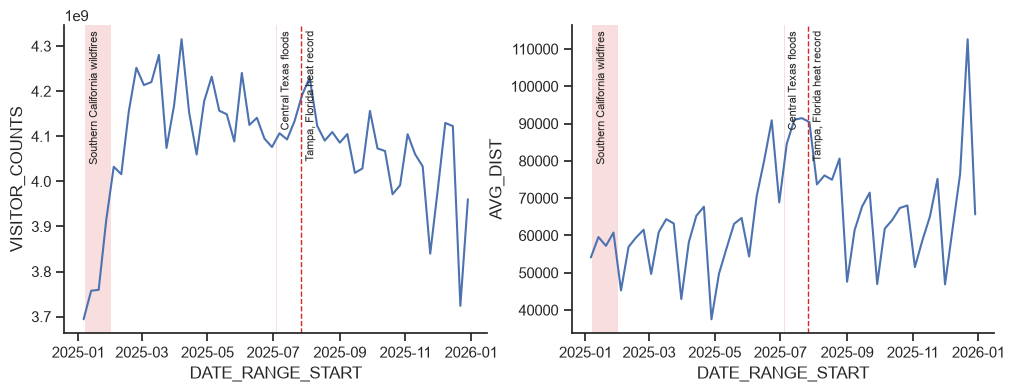

In [28]:
agg = df.group_by("DATE_RANGE_START").agg(
    pl.col("VISITOR_COUNTS").sum(),
    ((pl.col("AVG_DIST") * pl.col("VISITOR_COUNTS")).sum() / pl.col("VISITOR_COUNTS").sum()).alias("AVG_DIST")
)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="VISITOR_COUNTS",
    legend=False,
    ax=axes[0]
)
sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="AVG_DIST",
    legend=False,
    ax=axes[1]
)
for ax in axes:
    plot.plot_events(ax, events)
    sns.despine(ax=ax)

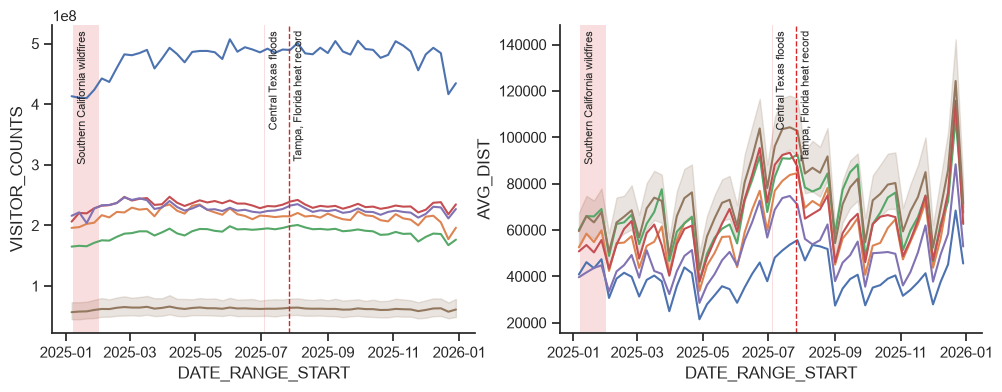

In [13]:
agg = df.group_by("DATE_RANGE_START", "CBSA_NAME", "CBSA_POP_RANK", "TOP_NAME").agg(
    pl.col("VISITOR_COUNTS").sum(),
    ((pl.col("AVG_DIST") * pl.col("VISITOR_COUNTS")).sum() / pl.col("VISITOR_COUNTS").sum()).alias("AVG_DIST")
).sort("CBSA_POP_RANK")
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="VISITOR_COUNTS",
    hue="TOP_NAME",
    legend=False,
    ax=axes[0]
)
sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="AVG_DIST",
    hue="TOP_NAME",
    legend=False,
    ax=axes[1]
)
for ax in axes:
    plot.plot_events(ax, events)
    sns.despine(ax=ax)

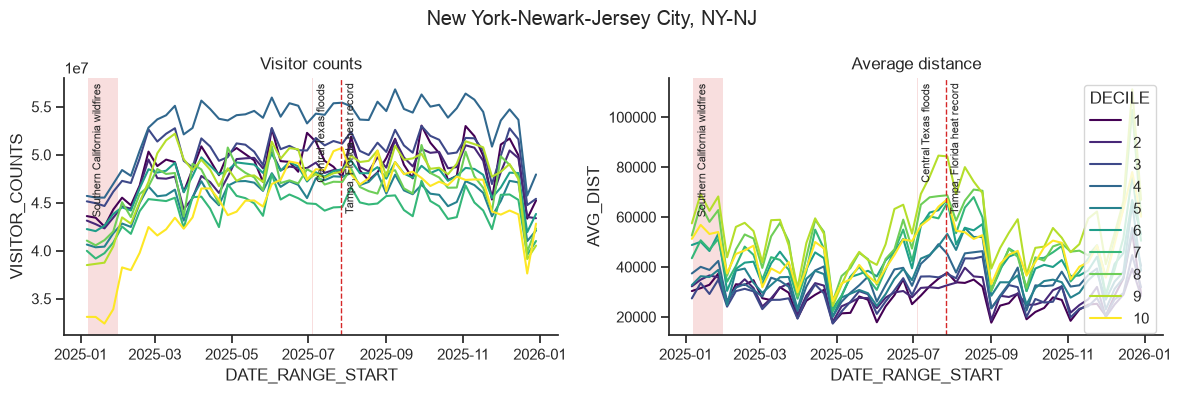

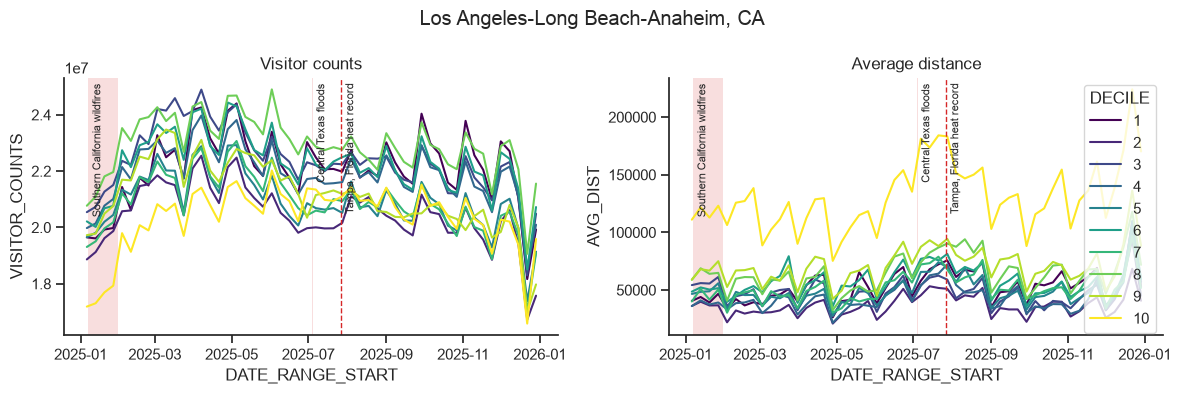

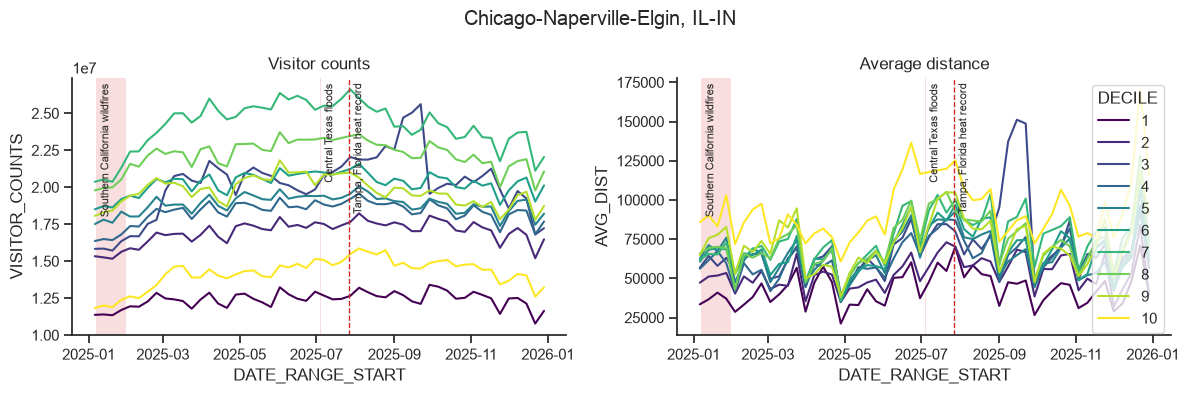

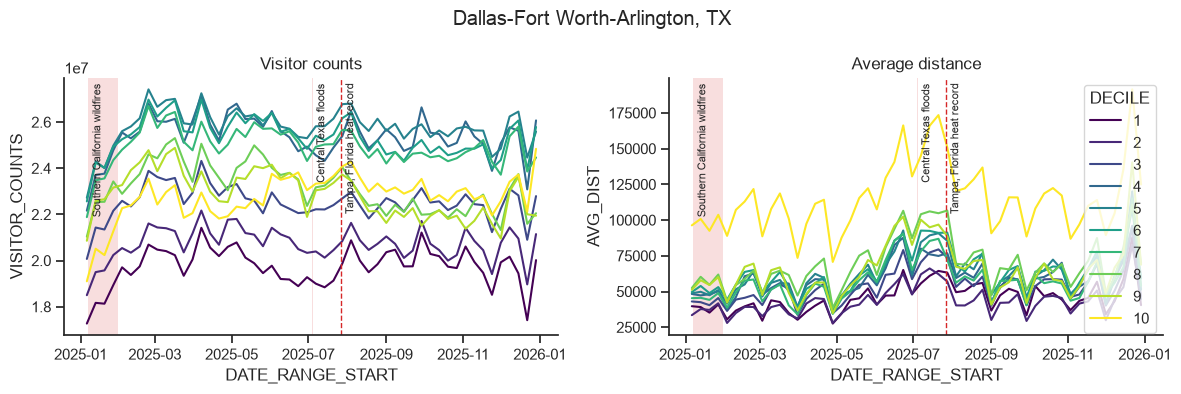

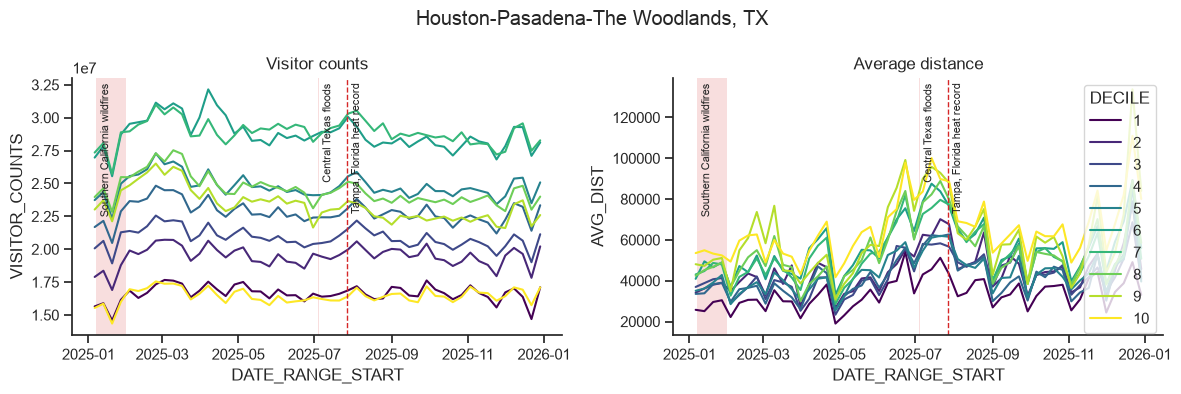

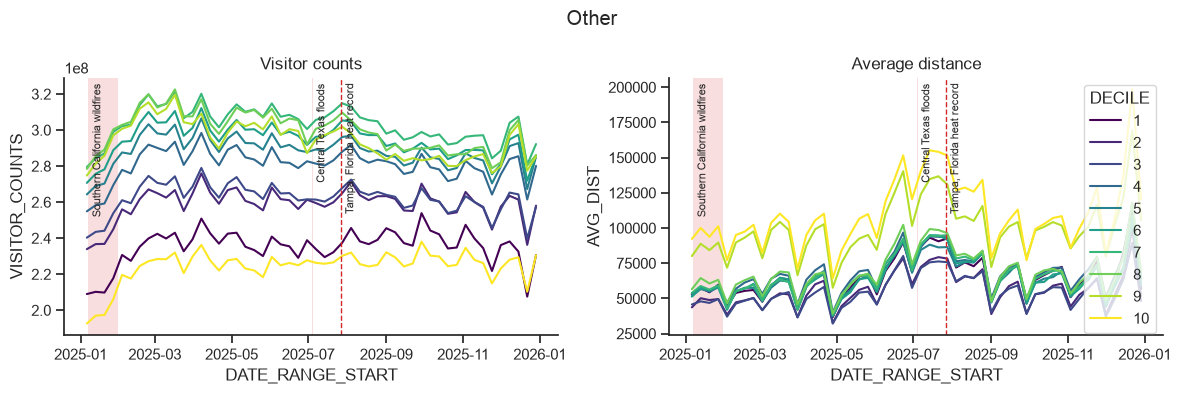

In [27]:
for (label,), group in (
    df.sort("CBSA_POP_RANK")
      .group_by("TOP_NAME", maintain_order=True)
):
    agg = (
        group
        .group_by("DATE_RANGE_START", "DECILE")
        .agg(
            pl.col("VISITOR_COUNTS").sum().alias("VISITOR_COUNTS"),
            (
                (pl.col("AVG_DIST") * pl.col("VISITOR_COUNTS")).sum()
                / pl.col("VISITOR_COUNTS").sum()
            ).alias("AVG_DIST"),
        )
        .sort(["DECILE", "DATE_RANGE_START"])
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.lineplot(
        data=agg,
        x="DATE_RANGE_START",
        y="VISITOR_COUNTS",
        hue="DECILE",
        palette="viridis",
        legend=False,
        ax=axes[0],
    )

    sns.lineplot(
        data=agg,
        x="DATE_RANGE_START",
        y="AVG_DIST",
        hue="DECILE",
        palette="viridis",
        legend="full",
        ax=axes[1],
    )

    axes[0].set_title("Visitor counts")
    axes[1].set_title("Average distance")
    fig.suptitle(label)

    for ax in axes:
        plot.plot_events(ax, events)
        sns.despine(ax=ax)

    fig.tight_layout()
    plt.show()